<a href="https://colab.research.google.com/github/Krishrdx/ML_to_GenAI_Journey/blob/main/Month_04_Deep_Learning/Week_03_ANN_Performance_Improving_Methods/Day_01_DropOut_Layers01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [4]:
x_train = np.linspace(-1,1,20)

In [5]:
x_train

array([-1.        , -0.89473684, -0.78947368, -0.68421053, -0.57894737,
       -0.47368421, -0.36842105, -0.26315789, -0.15789474, -0.05263158,
        0.05263158,  0.15789474,  0.26315789,  0.36842105,  0.47368421,
        0.57894737,  0.68421053,  0.78947368,  0.89473684,  1.        ])

In [6]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  ,
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475,
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [7]:
y_train

array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , -0.2443 ,
       -0.02445,  0.00135, -0.2006 ,  0.07475, -0.1422 ,  0.06515,
        0.15265,  0.3521 ,  0.28415,  0.5524 ,  0.23115,  0.20835,
        0.4211 ,  0.60485])

In [8]:
x_test = np.linspace(-1.1,1,20)
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

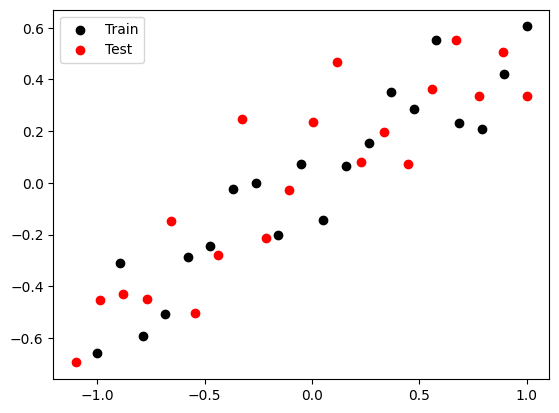

In [9]:
plt.scatter(x= x_train, y = y_train, c = 'black', label = 'Train')
plt.scatter(x= x_test, y = y_test, c = 'Red', label = 'Test')
plt.legend()
plt.show()

### REGRESSION MODEL

In [10]:
model1 = Sequential()

model1.add(Dense(128, activation='relu',input_dim = 1))
model1.add(Dense(128, activation='relu'))
model1.add(Dense(1, activation='linear'))

adam = Adam(learning_rate=0.001)

model1.compile(loss='mse', optimizer=adam, metrics=['mse'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
history1 = model1.fit(x_train, y_train, epochs=200, validation_data=(x_test, y_test), verbose=True)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1069 - mse: 0.1069 - val_loss: 0.0926 - val_mse: 0.0926
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.0842 - mse: 0.0842 - val_loss: 0.0736 - val_mse: 0.0736
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0653 - mse: 0.0653 - val_loss: 0.0584 - val_mse: 0.0584
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.0500 - mse: 0.0500 - val_loss: 0.0471 - val_mse: 0.0471
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.0383 - mse: 0.0383 - val_loss: 0.0391 - val_mse: 0.0391
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 0.0298 - mse: 0.0298 - val_loss: 0.0338 - val_mse: 0.0338
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.0239 - mse: 0.0239 - val_loss: 0.0309 - val_mse: 0.0309
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - loss: 0.0202 - mse: 0.0202 - val_loss: 0.0297 - val_mse: 0.0297
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0183 - 

In [ ]:
train_mse = model.evaluate(x_train, y_train, verbose=False)
test_mse = model.evaluate(x_test, y_test, verbose=False)

In [ ]:
train_mse

[0.05577854439616203, 0.05577854439616203]

In [ ]:
test_mse

[0.07285700738430023, 0.07285700738430023]

In [12]:
y_pred = model1.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


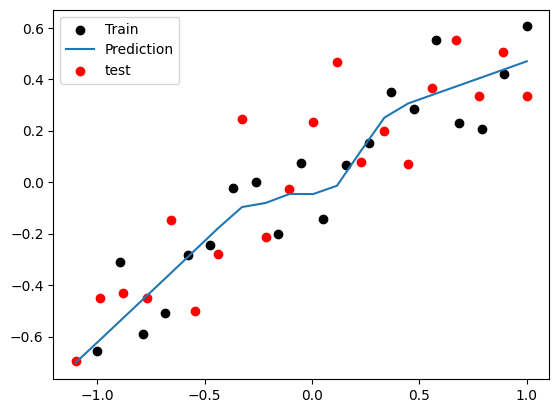

In [13]:
plt.figure()
plt.scatter(x= x_train, y = y_train, c = 'black', label = 'Train')
plt.plot(x_test,y_pred, label = 'Prediction')
plt.scatter(x= x_test, y = y_test, c = 'Red', label = 'test')

plt.legend()
plt.show()


### DROP OUT METHOD


In [32]:
model2 = Sequential()

model2.add(Dense(128, activation='relu',input_dim = 1))
model2.add(Dropout(0.2))
model2.add(Dense(128, activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(1, activation='linear'))

adam = Adam(learning_rate=0.001)

model2.compile(loss='mse', optimizer=adam, metrics=['mse'])


In [33]:
history2 = model2.fit(x_train, y_train, epochs=200, validation_data=(x_test, y_test), verbose=True)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.1223 - mse: 0.1223 - val_loss: 0.1098 - val_mse: 0.1098
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 0.1158 - mse: 0.1158 - val_loss: 0.0917 - val_mse: 0.0917
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 0.0930 - mse: 0.0930 - val_loss: 0.0762 - val_mse: 0.0762
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 0.0657 - mse: 0.0657 - val_loss: 0.0633 - val_mse: 0.0633
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.0532 - mse: 0.0532 - val_loss: 0.0528 - val_mse: 0.0528
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0535 - mse: 0.0535 - val_loss: 0.0447 - val_mse: 0.0447
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.0337 - mse: 0.0337 - val_loss: 0.0387 - val_mse: 0.0387
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0336 - mse: 0.0336 - val_loss: 0.0345 - val_mse: 0.0345
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0263 -

In [34]:
y_pred2 = model2.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


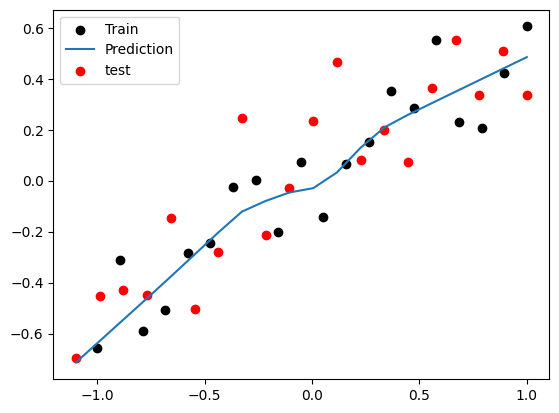

In [35]:
plt.figure()
plt.scatter(x= x_train, y = y_train, c = 'black', label = 'Train')
plt.plot(x_test,y_pred2, label = 'Prediction')
plt.scatter(x= x_test, y = y_test, c = 'Red', label = 'test')

plt.legend()
plt.show()


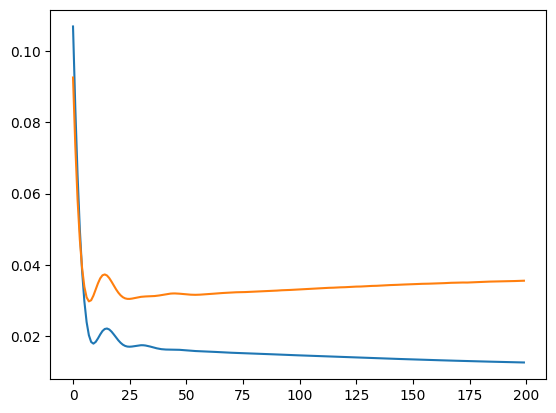

In [36]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])


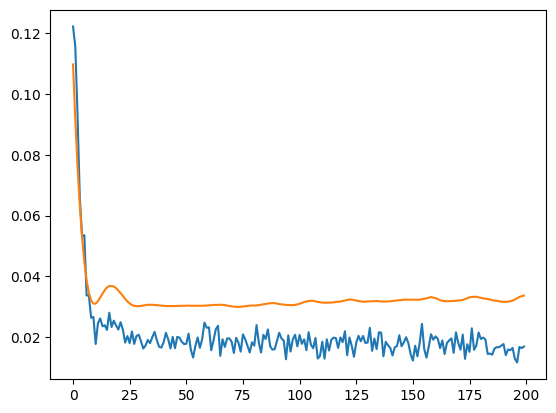

In [37]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])